# BITLUME Photonic Multiplication Error-Correction Simulator

## Component-Level Evaluation of Six Correction Schemes

This notebook implements the component-level simulator used to compare six correction
schemes for decomposed high-precision photonic multiplication.

| # | Scheme | Correction | FP16 sub-products |
|---|---|---|---|
| 1 | Baseline 4-bit | none | 9 |
| 2 | 4-bit corner LUT | exact correction of the MSB corner | 9 |
| 3 | Non-uniform slicing + LUT | split MSB nibble, correct four 2-bit corner terms | 16 |
| 4 | Parallel non-uniform slicing + LUT | replace the MSB corner with four corrected 2-bit terms | 12 |
| 5 | Low-bit congruent correction | exact 4-bit residue and nearest-congruent decode at every position | 9 |
| 6 | Low-bit decomposed correction | same decoder, residue reconstructed from a 16-entry table | 9 |

The canonical FP16 and FP32 experiments use fixed operand pairs. Noise is keyed by operand
pair and grid family so that schemes sharing a grid also share the same noise draws at
corresponding uncorrected positions. Final accuracy results use ideal exact table values.
A separate calibration-realism check evaluates whether noisy calibration measurements round
to the correct table entries under the simulated noise model.


## 1. Setup and Error Model

In [1]:
import sys
import math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

SEED = 42
rng = np.random.default_rng(SEED)

print("Environment")
print(f"  Python     : {sys.version.split()[0]}")
print(f"  NumPy      : {np.__version__}")
print(f"  pandas     : {pd.__version__}")
print(f"  matplotlib : {matplotlib.__version__}")
print(f"  Base seed  : {SEED}")

Environment
  Python     : 3.13.5
  NumPy      : 2.1.3
  pandas     : 2.2.3
  matplotlib : 3.10.0
  Base seed  : 42


In [2]:
# Error distribution parameters (mu, sigma) by photonic-multiplication operand width.
# Source: LightMat-HP, Fig. 5(b)-(e).
# The d=2 row is extrapolated from d=3..6. It is used only for uncorrected 2-bit controls
# and the calibration-realism model; runtime LUT-corrected 2-bit terms use exact table values.
ERROR_PARAMS = {
    2: {"mu": 0.0219, "sigma": 0.1693, "label": "bit width = 2 (extrapolated)"},
    3: {"mu": 0.2144, "sigma": 0.7048, "label": "bit width = 3"},
    4: {"mu": 0.2041, "sigma": 2.7588, "label": "bit width = 4"},
    5: {"mu": 0.9339, "sigma": 10.354, "label": "bit width = 5"},
    6: {"mu": 19.534, "sigma": 47.819, "label": "bit width = 6"},
}

print(f"{'Bit width':>10}  {'mu (mean)':>12}  {'sigma (std)':>12}  Notes")
print("-" * 72)
for bw, p in ERROR_PARAMS.items():
    note = "EXTRAPOLATED" if bw == 2 else ("characterised operating point" if bw == 4 else "")
    print(f"{bw:>10}  {p['mu']:>12.4f}  {p['sigma']:>12.4f}  {note}")

print()
print("The canonical operating point is the LightMat-HP d=4 row:")
print("  mu = 0.2041, sigma = 2.7588.")

 Bit width     mu (mean)   sigma (std)  Notes
------------------------------------------------------------------------
         2        0.0219        0.1693  EXTRAPOLATED
         3        0.2144        0.7048  
         4        0.2041        2.7588  characterised operating point
         5        0.9339       10.3540  
         6       19.5340       47.8190  

The canonical operating point is the LightMat-HP d=4 row:
  mu = 0.2041, sigma = 2.7588.


In [3]:
QUANT_BIT_WIDTH    = 4
MANTISSA_BIT_WIDTH = 12     # nibble-aligned FP16 surrogate used by this simulator
N_SAMPLES          = 500
K_CALIBRATION      = 1000

N_NIBBLES = math.ceil(MANTISSA_BIT_WIDTH / 4)
MAX_VAL   = 2 ** MANTISSA_BIT_WIDTH - 1
N_SLICES  = 2 * N_NIBBLES

assert QUANT_BIT_WIDTH in ERROR_PARAMS

mu    = ERROR_PARAMS[QUANT_BIT_WIDTH]["mu"]
sigma = ERROR_PARAMS[QUANT_BIT_WIDTH]["sigma"]

print("Configuration")
print(f"  Quantization bit width : {QUANT_BIT_WIDTH}")
print(f"  Mantissa bit width     : {MANTISSA_BIT_WIDTH} (nibble-aligned FP16 surrogate)")
print(f"  Nibbles per operand    : {N_NIBBLES}  ({N_NIBBLES}x{N_NIBBLES} = {N_NIBBLES**2} partial products)")
print(f"  Max mantissa value     : {MAX_VAL}")
print(f"  Noise model            : N(mu={mu}, sigma={sigma}) per noisy 4-bit partial product")
print(f"  Canonical pairs        : {N_SAMPLES}")
print(f"  Calibration repeats    : {K_CALIBRATION} per table entry")

Configuration
  Quantization bit width : 4
  Mantissa bit width     : 12 (nibble-aligned FP16 surrogate)
  Nibbles per operand    : 3  (3x3 = 9 partial products)
  Max mantissa value     : 4095
  Noise model            : N(mu=0.2041, sigma=2.7588) per noisy 4-bit partial product
  Canonical pairs        : 500
  Calibration repeats    : 1000 per table entry


## 2. Core Simulation Functions

In [4]:
def decompose_into_nibbles(value: int, n_nibbles: int) -> list:
    """Split a mantissa into n 4-bit nibbles, LSB first (index 0 = nibble 1)."""
    nibbles, remaining = [], int(value)
    for _ in range(n_nibbles):
        nibbles.append(remaining & 0xF)
        remaining >>= 4
    return nibbles


def reconstruct_from_nibbles(nibbles: list) -> int:
    return sum(nib * (16 ** i) for i, nib in enumerate(nibbles))


# -- Per-position noise (the key to fair, reproducible comparison) --------------
# Every scheme draws one standard-normal value per grid position from a SINGLE generator
# keyed by (operand pair, grid family), and draws ALL positions up front. Two consequences:
#   1. Correcting or skipping any position never shifts the noise on the others.
#   2. Baseline, 4-bit+LUT and parallel share the "nibble" family, so their common
#      positions get identical noise and their numbers are directly comparable.
FAM_NIBBLE, FAM_UNIFORM, FAM_NONUNIF = 0, 1, 2

def grid_standard_normals(a: int, b: int, positions: list, family: int) -> dict:
    """{position: standard_normal} for every position, drawn up front from one generator
    seeded by (a, b, family). Deterministic in (a, b), so any cell scoring a scheme on a given
    pair gets an identical result regardless of execution order."""
    pair_id = (int(a) << 32) | int(b)
    r = np.random.default_rng(pair_id * 4 + family)
    return {p: r.normal() for p in positions}


# -- Bit-width-aware noise selection -------------------------------------------
BITWIDTH_SCALED_NOISE = True
SIGMA_RATIO = {d: ERROR_PARAMS[d]["sigma"] / ERROR_PARAMS[4]["sigma"] for d in ERROR_PARAMS}
MU_RATIO    = {d: ERROR_PARAMS[d]["mu"]    / ERROR_PARAMS[4]["mu"]    for d in ERROR_PARAMS}

def noise_for(width_a: int, width_b: int, base_mu: float, base_sigma: float):
    """(mu, sigma) for a sub-product of widths (width_a, width_b), scaled to the larger
    width relative to the passed 4-bit reference. Mixed-width products are charged the larger
    width, since LightMat only characterises symmetric d x d products."""
    if not BITWIDTH_SCALED_NOISE:
        return base_mu, base_sigma
    d = max(width_a, width_b)
    return base_mu * MU_RATIO[d], base_sigma * SIGMA_RATIO[d]


print("Core functions defined (per-position noise).")
print(f"  2-bit sigma = {ERROR_PARAMS[4]['sigma']*SIGMA_RATIO[2]:.4f}, "
      f"4-bit sigma = {ERROR_PARAMS[4]['sigma']:.4f}")

Core functions defined (per-position noise).
  2-bit sigma = 0.1693, 4-bit sigma = 2.7588


In [5]:
# -- Reachable products and the readout pass-through --------------------------
# reachable_products is used by analysis cells. readout_correct keeps a common interface
# for raw and debiased readout modes; mode="raw" is a no-op.

_REACH_CACHE = {}

def reachable_products(wa: int, wb: int) -> np.ndarray:
    """The set of values a*b can take for operand widths (wa, wb)."""
    key = (wa, wb)
    if key not in _REACH_CACHE:
        _REACH_CACHE[key] = np.unique(
            np.outer(np.arange(2 ** wa), np.arange(2 ** wb)).ravel()).astype(float)
    return _REACH_CACHE[key]


def readout_correct(y: float, wa: int, wb: int, base_mu: float, base_sigma: float,
                    mode: str = "raw") -> float:
    """Pass-through readout stage. mode='raw' returns the value untouched."""
    if mode == "raw":
        return y
    m, _ = noise_for(wa, wb, base_mu, base_sigma)
    if mode == "debias":
        return y - m
    raise ValueError(f"unknown readout mode {mode!r}")


print("Readout pass-through defined. Reachable set sizes:")
for (wa, wb) in [(2, 2), (4, 4)]:
    S = reachable_products(wa, wb)
    print(f"  {wa}x{wb}: {len(S)} distinct products spanning 0..{int(S[-1])}")

Readout pass-through defined. Reachable set sizes:
  2x2: 7 distinct products spanning 0..9
  4x4: 90 distinct products spanning 0..225


## 3. Schemes 1 and 2: Baseline and 4-bit Corner LUT

**Scheme 1, baseline.** The mantissa is split into 4-bit nibbles and every pairwise product
is computed with the simulated photonic error, then shifted and accumulated digitally.

**Scheme 2, 4-bit corner LUT.** The same 4-bit grid is used, except the most significant
corner product is replaced by its exact lookup-table value. The scheme adds no photonic
sub-products, but it requires a 256-entry 8-bit table for the corrected corner.


In [6]:
# -- Scheme 1: Baseline 4-bit BITLUME ------------------------------------------
def bitlume_multiply(a, b, n_nibbles, mu, sigma, rng=None, readout="raw", verbose=False) -> dict:
    ground_truth = int(a) * int(b)
    a_nibbles = decompose_into_nibbles(a, n_nibbles)
    b_nibbles = decompose_into_nibbles(b, n_nibbles)

    positions = [(i, j) for i in range(1, n_nibbles + 1) for j in range(1, n_nibbles + 1)]
    Z = grid_standard_normals(a, b, positions, FAM_NIBBLE)
    m4, s4 = noise_for(4, 4, mu, sigma)

    photonic_sum, grid = 0.0, {}
    for (i, j) in positions:
        a_nib, b_nib = a_nibbles[i - 1], b_nibbles[j - 1]
        noisy_pp = a_nib * b_nib + m4 + s4 * Z[(i, j)]
        pp_value = readout_correct(noisy_pp, 4, 4, mu, sigma, readout)
        shift = 4 * (i + j - 2)
        contribution = pp_value * (2 ** shift)
        photonic_sum += contribution
        grid[(i, j)] = {"a_nib": a_nib, "b_nib": b_nib, "true_pp": a_nib * b_nib,
                        "noisy_pp": noisy_pp, "pp_value": pp_value,
                        "shift": shift, "contribution": contribution}

    abs_error = photonic_sum - ground_truth
    rel_error = (abs(abs_error) / ground_truth * 100) if ground_truth != 0 else 0.0

    if verbose:
        print(f"  a = {a}, b = {b}   readout = {readout}")
        print(f"  {'Pos':>6}  {'a_i':>4}  {'b_j':>4}  {'True':>6}  {'Noisy':>10}  {'Readout':>9}  {'Shift':>6}  {'Contribution':>16}")
        for (i, j), e in grid.items():
            print(f"  ({i},{j}):  {e['a_nib']:>4}  {e['b_nib']:>4}  {e['true_pp']:>6}  "
                  f"{e['noisy_pp']:>10.4f}  {e['pp_value']:>9.3f}  <<{e['shift']:>4}  {e['contribution']:>16.2f}")
        print(f"  Ground truth : {ground_truth:,}")
        print(f"  Photonic sum : {photonic_sum:,.4f}")
        print(f"  Absolute err : {abs_error:+.4f}")
        print(f"  Relative err : {rel_error:.6f}%")

    return {"a": a, "b": b, "ground_truth": ground_truth, "photonic_result": photonic_sum,
            "absolute_error": abs_error, "relative_error_pct": rel_error,
            "partial_products_grid": grid}


# -- Scheme 2: 4-bit + LUT on the MSB corner -----------------------------------
def bitlume_multiply_with_lut(a, b, n_nibbles, mu, sigma, rng=None,
                              lut=None, lut_position="msb", readout="raw", verbose=False) -> dict:
    ground_truth = int(a) * int(b)
    a_nibbles = decompose_into_nibbles(a, n_nibbles)
    b_nibbles = decompose_into_nibbles(b, n_nibbles)

    positions = [(i, j) for i in range(1, n_nibbles + 1) for j in range(1, n_nibbles + 1)]
    Z = grid_standard_normals(a, b, positions, FAM_NIBBLE)
    m4, s4 = noise_for(4, 4, mu, sigma)

    photonic_sum, grid = 0.0, {}
    for (i, j) in positions:
        a_nib, b_nib = a_nibbles[i - 1], b_nibbles[j - 1]
        is_msb_corner = (i == n_nibbles) and (j == n_nibbles)
        use_lut = (lut_position == "all") or (lut_position == "msb" and is_msb_corner)
        if use_lut:
            pp_value = float(lut[a_nib, b_nib]); corrected = True
        else:
            noisy = a_nib * b_nib + m4 + s4 * Z[(i, j)]
            pp_value = readout_correct(noisy, 4, 4, mu, sigma, readout); corrected = False
        shift = 4 * (i + j - 2)
        contribution = pp_value * (2 ** shift)
        photonic_sum += contribution
        grid[(i, j)] = {"a_nib": a_nib, "b_nib": b_nib, "true_pp": a_nib * b_nib,
                        "pp_value": pp_value, "corrected": corrected,
                        "shift": shift, "contribution": contribution}

    abs_error = photonic_sum - ground_truth
    rel_error = (abs(abs_error) / ground_truth * 100) if ground_truth != 0 else 0.0
    return {"a": a, "b": b, "ground_truth": ground_truth, "photonic_result": photonic_sum,
            "absolute_error": abs_error, "relative_error_pct": rel_error,
            "partial_products_grid": grid}


print("Baseline and 4-bit+LUT multiply functions defined.")

Baseline and 4-bit+LUT multiply functions defined.


In [7]:
# -- LUT tables ---------------------------------------------------------------
# First reproduce the calibration-realism check by averaging K noisy reads and rounding.
# Final accuracy scoring uses ideal exact tables so architectural behaviour is separated
# from calibration error.

calib_rng = np.random.default_rng(SEED + 200)
LUT_measured = np.zeros((16, 16), dtype=int)
for a_nib in range(16):
    for b_nib in range(16):
        meas = calib_rng.normal(loc=a_nib * b_nib + mu, scale=sigma, size=K_CALIBRATION)
        LUT_measured[a_nib, b_nib] = int(round(meas.mean()))
n_wrong4 = sum(1 for i in range(16) for j in range(16) if LUT_measured[i, j] != i * j)

lut2_rng = np.random.default_rng(SEED + 800)
LUT_2bit_measured = np.zeros((4, 4), dtype=int)
_m2c, _s2c = noise_for(2, 2, mu, sigma)
for ai in range(4):
    for bj in range(4):
        meas = lut2_rng.normal(loc=ai * bj + _m2c, scale=_s2c, size=K_CALIBRATION)
        LUT_2bit_measured[ai, bj] = int(round(meas.mean()))
n_wrong2 = sum(1 for i in range(4) for j in range(4) if LUT_2bit_measured[i, j] != i * j)

# Idealized tables: LUT[a,b] = a*b exactly. These separate architectural accuracy
# from calibration noise, and are the tables used by every correcting scheme below.
LUT      = np.array([[i * j for j in range(16)] for i in range(16)], dtype=int)
LUT_2bit = np.array([[i * j for j in range(4)]  for i in range(4)],  dtype=int)

print(f"LUT calibration at K = {K_CALIBRATION}")
print(f"  16x16 nibble LUT : {256 - n_wrong4}/256 entries correct when measured")
print(f"  4x4   2-bit  LUT : {16 - n_wrong2}/16 entries correct when measured")
print()
print("Idealized tables built (LUT[a,b] = a*b by construction). These are used by every")
print("correcting scheme from here on.")

LUT calibration at K = 1000
  16x16 nibble LUT : 256/256 entries correct when measured
  4x4   2-bit  LUT : 16/16 entries correct when measured

Idealized tables built (LUT[a,b] = a*b by construction). These are used by every
correcting scheme from here on.


## 4. Schemes 3 and 4: Non-Uniform and Parallel Non-Uniform Slicing

**Scheme 3, non-uniform slicing.** The MSB nibble of each operand is split into two 2-bit
halves while the lower nibbles remain 4-bit. The four positions where both operands are
2-bit are corrected with a 16-entry table. The FP16 grid grows from 9 to 16 sub-products.

**Scheme 4, parallel non-uniform slicing.** The original 4-bit grid is retained except for
the full-width MSB corner. That corner is replaced by four exact 2-bit terms from the same
16-entry table, giving 12 FP16 sub-products.

The corner replacement is algebraically exact. With
\(a_3=4a_H+a_L\) and \(b_3=4b_H+b_L\),

\[
16a_Hb_H + 4a_Hb_L + 4a_Lb_H + a_Lb_L
= (4a_H+a_L)(4b_H+b_L)
= a_3b_3.
\]

Schemes 2 and 4 therefore supply the same exact MSB-corner contribution. Their remaining
4-bit grid positions are identical and use the same keyed noise draws. Under the ideal-table
model they have the same numerical behaviour, while their implementation costs differ.


In [8]:
# -- Scheme 3: Non-uniform slicing (MSB nibble split into 2-bit halves) --------
def decompose_nonuniform(value: int, n_nibbles: int):
    """Sub-operands as (val, width, offset), LSB first. Lower nibbles stay 4-bit; the MSB
    nibble splits into 2-bit lo and hi halves."""
    nibbles = decompose_into_nibbles(value, n_nibbles)
    subops = []
    for k in range(n_nibbles - 1):
        subops.append({"val": nibbles[k], "width": 4, "offset": 4 * k, "name": f"x{k+1}"})
    msb = nibbles[n_nibbles - 1]
    base_off = 4 * (n_nibbles - 1)
    subops.append({"val": msb & 0x3,        "width": 2, "offset": base_off,     "name": f"x{n_nibbles}_lo"})
    subops.append({"val": (msb >> 2) & 0x3, "width": 2, "offset": base_off + 2, "name": f"x{n_nibbles}_hi"})
    return subops


def bitlume_multiply_nonuniform(a, b, n_nibbles, mu, sigma, rng,
                                lut2=None, use_lut=True, readout="raw", verbose=False) -> dict:
    ground_truth = int(a) * int(b)
    a_sub = decompose_nonuniform(a, n_nibbles)
    b_sub = decompose_nonuniform(b, n_nibbles)

    _pos_nu = [(i, j) for i in range(len(a_sub)) for j in range(len(b_sub))]
    Znu = grid_standard_normals(a, b, _pos_nu, FAM_NONUNIF)

    photonic_sum, rows = 0.0, []
    for i_nu, sa in enumerate(a_sub):
        for j_nu, sb in enumerate(b_sub):
            both_2bit = (sa["width"] == 2) and (sb["width"] == 2)
            corrected = bool(use_lut and both_2bit)
            if corrected:
                pp = float(lut2[sa["val"], sb["val"]])
            else:
                _m, _s = noise_for(sa["width"], sb["width"], mu, sigma)
                noisy = sa["val"] * sb["val"] + _m + _s * Znu[(i_nu, j_nu)]
                pp = readout_correct(noisy, sa["width"], sb["width"], mu, sigma, readout)
            shift = sa["offset"] + sb["offset"]
            photonic_sum += pp * (2 ** shift)
            rows.append((sa["name"], sb["name"], sa["val"], sb["val"],
                         sa["val"] * sb["val"], pp, shift, corrected))

    abs_err = photonic_sum - ground_truth
    rel_err = abs(abs_err) / ground_truth * 100 if ground_truth != 0 else 0.0
    return {"a": a, "b": b, "ground_truth": ground_truth, "photonic_result": photonic_sum,
            "absolute_error": abs_err, "relative_error_pct": rel_err,
            "n_subproducts": len(rows)}


# -- Scheme 4: Parallel non-uniform slicing + corner LUT -----------------------
# The n x n 4-bit grid is kept intact except for the MSB corner (a_n x b_n), which is
# skipped. In parallel, the four 2-bit corner sub-products are computed and LUT-corrected,
# and their shifted sum replaces the skipped position.
def bitlume_multiply_parallel(a, b, n_nibbles, mu, sigma, rng,
                              lut2=None, use_lut=True, readout="raw", verbose=False) -> dict:
    ground_truth = int(a) * int(b)
    a_nib = decompose_into_nibbles(a, n_nibbles)
    b_nib = decompose_into_nibbles(b, n_nibbles)
    msb = n_nibbles - 1

    _pos_par = [(i, j) for i in range(n_nibbles) for j in range(n_nibbles)]
    Zpar = grid_standard_normals(a, b, _pos_par, FAM_NIBBLE)   # SAME family as baseline
    _m4p, _s4p = noise_for(4, 4, mu, sigma)

    photonic_sum, n_ops, rows = 0.0, 0, []

    for i in range(n_nibbles):
        for j in range(n_nibbles):
            if i == msb and j == msb:
                continue                                   # skipped, handled on the aux path
            noisy = a_nib[i] * b_nib[j] + _m4p + _s4p * Zpar[(i, j)]
            pp = readout_correct(noisy, 4, 4, mu, sigma, readout)
            shift = 4 * (i + j)
            photonic_sum += pp * (2 ** shift)
            n_ops += 1
            rows.append((f"a{i+1} x b{j+1}", a_nib[i], b_nib[j], pp, shift, False))

    a_lo, a_hi = a_nib[msb] & 0x3, (a_nib[msb] >> 2) & 0x3
    b_lo, b_hi = b_nib[msb] & 0x3, (b_nib[msb] >> 2) & 0x3
    base = 4 * (msb + msb)
    corner = [("hi x hi", a_hi, b_hi, base + 4),
              ("hi x lo", a_hi, b_lo, base + 2),
              ("lo x hi", a_lo, b_hi, base + 2),
              ("lo x lo", a_lo, b_lo, base)]
    _m2p, _s2p = noise_for(2, 2, mu, sigma)
    _Zaux = np.random.default_rng(((int(a) << 32) | int(b)) * 4 + FAM_NONUNIF + 7)
    for name, av, bv, shift in corner:
        if use_lut:
            pp = float(lut2[av, bv])
        else:
            noisy = av * bv + _m2p + _s2p * _Zaux.normal()
            pp = readout_correct(noisy, 2, 2, mu, sigma, readout)
        photonic_sum += pp * (2 ** shift)
        n_ops += 1
        rows.append((f"a_n {name}", av, bv, pp, shift, bool(use_lut)))

    abs_err = photonic_sum - ground_truth
    rel_err = abs(abs_err) / ground_truth * 100 if ground_truth != 0 else 0.0
    return {"a": a, "b": b, "ground_truth": ground_truth, "photonic_result": photonic_sum,
            "absolute_error": abs_err, "relative_error_pct": rel_err,
            "n_subproducts": n_ops}


print("Non-uniform and parallel non-uniform schemes defined.")
_ex = bitlume_multiply_parallel(3372, 2765, N_NIBBLES, mu, sigma,
                                np.random.default_rng(0), lut2=LUT_2bit)
print(f"  Parallel FP16 operation count: {_ex['n_subproducts']} (expected 12)")

Non-uniform and parallel non-uniform schemes defined.
  Parallel FP16 operation count: 12 (expected 12)


## 5. Canonical Operands and Baseline Validation

In [9]:
# Canonical operand pairs, generated once and reused by every comparison.
allA = np.random.default_rng(SEED + 1400).integers(0, MAX_VAL + 1, size=N_SAMPLES)
allB = np.random.default_rng(SEED + 1401).integers(0, MAX_VAL + 1, size=N_SAMPLES)
N_ALL = N_SAMPLES

# Baseline regression check.
baseline_results = [bitlume_multiply(int(a), int(b), N_NIBBLES, mu, sigma)
                    for a, b in zip(allA, allB)]
baseline_abs = np.array([abs(r["absolute_error"]) for r in baseline_results])

EXPECTED_BASELINE_MEAN_ABS = 152411.29
print(f"Baseline mean |absolute error| : {baseline_abs.mean():.2f}")
print(f"Expected regression value      : {EXPECTED_BASELINE_MEAN_ABS:.2f}")
assert abs(baseline_abs.mean() - EXPECTED_BASELINE_MEAN_ABS) < 0.01, \
    "Baseline regression check failed."
print("Regression check passed.")

Baseline mean |absolute error| : 152411.29
Expected regression value      : 152411.29
Regression check passed.


## 6. Schemes 1 to 4: FP16 Results

In [10]:
# -- Score the four carried schemes on the canonical pairs --------------------
def run_carried(a, b, scheme):
    a, b = int(a), int(b)
    if scheme == "base":
        return bitlume_multiply(a, b, N_NIBBLES, mu, sigma)
    if scheme == "lut4":
        return bitlume_multiply_with_lut(a, b, N_NIBBLES, mu, sigma,
                                         lut=LUT, lut_position="msb")
    if scheme == "nonuni":
        return bitlume_multiply_nonuniform(a, b, N_NIBBLES, mu, sigma, None,
                                           lut2=LUT_2bit, use_lut=True)
    if scheme == "parallel":
        return bitlume_multiply_parallel(a, b, N_NIBBLES, mu, sigma, None,
                                         lut2=LUT_2bit, use_lut=True)
    raise ValueError(scheme)


CARRIED = {
    "base":     ("1. Baseline 4-bit",                  N_NIBBLES ** 2),
    "lut4":     ("2. 4-bit + LUT (MSB corner)",        N_NIBBLES ** 2),
    "nonuni":   ("3. Non-uniform slicing + LUT",       (N_NIBBLES + 1) ** 2),
    "parallel": ("4. Parallel non-uniform + LUT",      N_NIBBLES ** 2 + 3),
}

results = {}
for s in CARRIED:
    rs = [run_carried(a, b, s) for a, b in zip(allA, allB)]
    ae = np.array([abs(r["absolute_error"]) for r in rs])
    re = np.array([r["relative_error_pct"] for r in rs])
    results[s] = {"mean_abs": ae.mean(), "median_abs": np.median(ae),
                  "mean_rel": re.mean(), "median_rel": np.median(re),
                  "abs_errs": ae, "nsub": CARRIED[s][1], "label": CARRIED[s][0]}

b_ma = results["base"]["mean_abs"]

print(f"Schemes 1 to 4 | FP16 ({MANTISSA_BIT_WIDTH}-bit mantissa) | N = {N_ALL} | sigma = {sigma}")
print("=" * 104)
print(f"{'Scheme':<34}{'Sub-prods':>11}{'Overhead':>10}{'Mean |Abs Err|':>17}"
      f"{'vs base':>10}{'Median':>14}{'Mean Rel%':>12}")
print("-" * 104)
for s in ["base", "lut4", "nonuni", "parallel"]:
    d = results[s]
    oh = (d["nsub"] - N_NIBBLES ** 2) / N_NIBBLES ** 2 * 100
    print(f"{d['label']:<34}{d['nsub']:>11}{oh:>9.1f}%{d['mean_abs']:>17,.2f}"
          f"{(d['mean_abs']-b_ma)/b_ma*100:>9.1f}%{d['median_abs']:>14,.2f}{d['mean_rel']:>11.4f}%")
print("=" * 104)
print()
# Verify the structural Scheme 2 / Scheme 4 equivalence on the canonical set.
_s2_out = np.array([
    bitlume_multiply_with_lut(int(a), int(b), N_NIBBLES, mu, sigma,
                              lut=LUT, lut_position="msb")["photonic_result"]
    for a, b in zip(allA, allB)
])
_s4_out = np.array([
    bitlume_multiply_parallel(int(a), int(b), N_NIBBLES, mu, sigma, None,
                              lut2=LUT_2bit, use_lut=True)["photonic_result"]
    for a, b in zip(allA, allB)
])
_max_s24_diff = np.max(np.abs(_s2_out - _s4_out))
assert np.allclose(_s2_out, _s4_out, rtol=1e-12, atol=1e-8)

_corner_bad = []
for a3 in range(16):
    for b3 in range(16):
        aH, aL = a3 >> 2, a3 & 3
        bH, bL = b3 >> 2, b3 & 3
        corner4 = 16*aH*bH + 4*aH*bL + 4*aL*bH + aL*bL
        if corner4 != a3*b3:
            _corner_bad.append((a3, b3))
assert not _corner_bad

print()
print("Scheme 2 / Scheme 4 equivalence check")
print(f"  Corner identity                         : 256/256 nibble pairs")
print(f"  Canonical reconstructed max difference : {_max_s24_diff:.2e}")
print("  Any non-zero remainder is floating-point accumulation-order round-off.")
print()
print("Scheme 3 has higher error and a larger sub-product count than either corner-correction")
print("implementation. Scheme 4 trades three additional FP16 sub-products for a 16-entry")
print("table instead of Scheme 2's 256-entry table.")

Schemes 1 to 4 | FP16 (12-bit mantissa) | N = 500 | sigma = 2.7588
Scheme                              Sub-prods  Overhead   Mean |Abs Err|   vs base        Median   Mean Rel%
--------------------------------------------------------------------------------------------------------
1. Baseline 4-bit                           9      0.0%       152,411.29      0.0%    124,129.64    61.6462%
2. 4-bit + LUT (MSB corner)                 9      0.0%        12,627.04    -91.7%     10,627.22     4.6431%
3. Non-uniform slicing + LUT               16     77.8%        53,263.36    -65.1%     43,325.76    35.6115%
4. Parallel non-uniform + LUT              12     33.3%        12,627.04    -91.7%     10,627.22     4.6431%


Scheme 2 / Scheme 4 equivalence check
  Corner identity                         : 256/256 nibble pairs
  Canonical reconstructed max difference : 1.86e-09
  Any non-zero remainder is floating-point accumulation-order round-off.

Scheme 3 has higher error and a larger sub-product c

## 7. Scheme 5: Low-Bit Congruent Correction

### 7.1 Objective

Schemes 2 to 4 correct the most significant corner. Scheme 5 instead uses exact low-bit
information at every 4-bit grid position while retaining the baseline photonic sub-product
count.

### 7.2 Exact residue information

The operands are already present digitally because they drive the modulators. The simulator
therefore treats them as available to the correction logic, although routing, area and
energy for that digital path are not modelled here.

For a chosen width \(k\),

\[
(a b) \bmod 2^k
=
\big((a \bmod 2^k)(b \bmod 2^k)\big) \bmod 2^k.
\]

A lookup table can therefore provide the exact residue \(r=(ab)\bmod 2^k\). The correction
does not splice this residue into the readout. Instead, it chooses the value congruent to
\(r\) modulo \(2^k\) that is nearest to the debiased photonic readout.

### 7.3 Why splicing fails

A useful control is the intuitive splice rule, which keeps the high bits of the noisy
readout and overwrites its low \(k\) bits with the exact residue. This fails because the
photonic error is additive and can cross a binary carry boundary. The worked example below
uses a true product of 130 and a readout of 127. The error is only -3, but keeping the
readout's high bits selects the wrong block.

The congruent decoder avoids this problem by comparing neighbouring values with the required
residue and selecting the nearest one. It adds digital post-processing but does not increase
the photonic sub-product count.

### 7.4 Choice of \(k\)

Candidates with the same \(k\)-bit residue are spaced by \(2^k\), giving a nearest-candidate
decision margin of \(2^{k-1}\). At \(k=4\) the margin is 8, or about 2.9 times the
characterised 4-bit noise standard deviation of 2.7588. The sweep in Section 7.6 shows the
resulting accuracy and table-size trade-off.


In [11]:
# --------------------------------------------------------------
#            SCHEME 5: USER-CONFIGURABLE PARAMETERS
# --------------------------------------------------------------

K_LOWBITS = 4      # number of low bits supplied by the table

# The table is indexed by (a mod 2^k, b mod 2^k). For d-bit operands, once k >= d the
# operands are already fully specified, so the entry count saturates at 2^d x 2^d and only
# the stored width keeps growing.
def lowbit_table(k, d=4):
    """T[x, y] = (x * y) mod 2^k for the low k bits of each operand."""
    idx = 2 ** min(k, d)
    x = np.arange(idx)
    return (np.outer(x, x) % (2 ** k)).astype(int)

def table_cost(k, d=4):
    """(entries, bits per entry, total bits) for the low-bit table."""
    ent = (2 ** min(k, d)) ** 2
    return ent, k, ent * k

print("Low-bit table, indexed by the low k bits of each operand")
print("=" * 74)
print(f"{'k':>3}{'entries':>10}{'bits/entry':>12}{'total bits':>12}{'note':>36}")
print("-" * 74)
for k in range(0, 9):
    e, w, t = table_cost(k)
    note = ("baseline, no correction" if k == 0 else
            "exact low nibble" if k == 4 else
            "entire product, = scheme 2 LUT" if k == 8 else "")
    print(f"{k:>3}{e:>10}{w:>12}{t:>12}{note:>36}")
print("=" * 74)
print()
print(f"Selected operating point: k = {K_LOWBITS}, "
      f"{table_cost(K_LOWBITS)[0]} entries x {K_LOWBITS} bits = {table_cost(K_LOWBITS)[2]} bits")
print(f"Scheme 2's corner LUT for comparison: 256 entries x 8 bits = 2048 bits")

Low-bit table, indexed by the low k bits of each operand
  k   entries  bits/entry  total bits                                note
--------------------------------------------------------------------------
  0         1           0           0             baseline, no correction
  1         4           1           4                                    
  2        16           2          32                                    
  3        64           3         192                                    
  4       256           4        1024                    exact low nibble
  5       256           5        1280                                    
  6       256           6        1536                                    
  7       256           7        1792                                    
  8       256           8        2048      entire product, = scheme 2 LUT

Selected operating point: k = 4, 256 entries x 4 bits = 1024 bits
Scheme 2's corner LUT for comparison: 256 entries x 8 bits = 

In [12]:
# -- The splice rule fails, demonstrated on a single sub-product --------------
DEMO_T, DEMO_K = 130, 3       # 13 x 10 = 130

print(f"Why the splice rule fails: sub-product 13 x 10 = {DEMO_T}, k = {DEMO_K}")
print(f"True value {DEMO_T} = {DEMO_T:08b}, table supplies low {DEMO_K} bits = "
      f"{DEMO_T % 2**DEMO_K} ({DEMO_T % 2**DEMO_K:0{DEMO_K}b})")
print("=" * 86)
print(f"{'readout':>9}{'binary':>11}{'splice result':>16}{'congruent result':>19}{'outcome':>28}")
print("-" * 86)
for y in range(DEMO_T - 5, DEMO_T + 6):
    r = DEMO_T % (2 ** DEMO_K)
    spl = ((y >> DEMO_K) << DEMO_K) | r
    base = np.floor((y - r) / (2 ** DEMO_K))
    cong = int(min([(base + o) * (2 ** DEMO_K) + r for o in (-1, 0, 1)],
                   key=lambda u: abs(u - y)))
    tag = ("both correct" if spl == DEMO_T and cong == DEMO_T else
           f"splice wrong by {spl-DEMO_T:+d}, congruent OK" if cong == DEMO_T else "both wrong")
    print(f"{y:>9}{format(y,'08b'):>11}{spl:>16}{cong:>19}{tag:>28}")
print("=" * 86)
print()
print(f"  true    {DEMO_T:>3} = {DEMO_T:08b}")
print(f"  readout {127:>3} = {127:08b}")
print(f"  differing bit positions: {[i for i in range(8) if ((DEMO_T>>i)&1)!=((127>>i)&1)]}")
print()
print("An error of -3 changes seven bit positions, because the readout falls below the")
print("128 boundary. The splice rule keeps the wrong high bits (120 instead of 128) and")
print("returns 122. The congruent rule reaches into the next block and returns 130.")

Why the splice rule fails: sub-product 13 x 10 = 130, k = 3
True value 130 = 10000010, table supplies low 3 bits = 2 (010)
  readout     binary   splice result   congruent result                     outcome
--------------------------------------------------------------------------------------
      125   01111101             122                122                  both wrong
      126   01111110             122                122                  both wrong
      127   01111111             122                130splice wrong by -8, congruent OK
      128   10000000             130                130                both correct
      129   10000001             130                130                both correct
      130   10000010             130                130                both correct
      131   10000011             130                130                both correct
      132   10000100             130                130                both correct
      133   10000101          

In [13]:
# -- Scheme 5 multiply --------------------------------------------------------
def bitlume_multiply_lowbit(a, b, n_nibbles, mu, sigma, k=None, rule="congruent",
                            corner_only=False, verbose=False) -> dict:
    """Baseline 4-bit grid with LUT-assisted low-bit correction at every position.

    rule = 'congruent' : take the value congruent to the table residue nearest the readout
    rule = 'splice'    : keep the readout's high bits, overwrite the low k bits
    rule = 'raw'       : no correction (reproduces the baseline exactly)

    Adds no photonic sub-products: the correction is a table read plus a comparison."""
    k = K_LOWBITS if k is None else k
    ground_truth = int(a) * int(b)
    a_nibbles = decompose_into_nibbles(a, n_nibbles)
    b_nibbles = decompose_into_nibbles(b, n_nibbles)

    positions = [(i, j) for i in range(1, n_nibbles + 1) for j in range(1, n_nibbles + 1)]
    Z = grid_standard_normals(a, b, positions, FAM_NIBBLE)   # same family as the baseline
    m4, s4 = noise_for(4, 4, mu, sigma)
    M = 2 ** k

    photonic_sum, grid = 0.0, {}
    for (i, j) in positions:
        av, bv = a_nibbles[i - 1], b_nibbles[j - 1]
        true_pp = av * bv
        noisy = true_pp + m4 + s4 * Z[(i, j)]
        z = noisy - m4                                       # debias
        apply_here = (not corner_only) or (i == n_nibbles and j == n_nibbles)

        if rule == "raw" or not apply_here:
            pp = noisy
        else:
            r = true_pp % M                                  # from the low-bit table
            if rule == "splice":
                pp = float(((int(np.rint(z)) >> k) << k) | r)
            elif rule == "congruent":
                blk = np.floor((z - r) / M)
                pp = float(min([(blk + o) * M + r for o in (-1, 0, 1)],
                               key=lambda u: abs(u - z)))
            else:
                raise ValueError(rule)

        shift = 4 * (i + j - 2)
        photonic_sum += pp * (2 ** shift)
        grid[(i, j)] = {"a_nib": av, "b_nib": bv, "true_pp": true_pp,
                        "noisy_pp": noisy, "pp_value": pp, "shift": shift}

    abs_error = photonic_sum - ground_truth
    rel_error = abs(abs_error) / ground_truth * 100 if ground_truth else 0.0

    if verbose:
        print(f"  a = {a}, b = {b}, k = {k}, rule = {rule}")
        print(f"  {'Pos':>6}{'a_i':>5}{'b_j':>5}{'True':>7}{'Noisy':>11}{'Corrected':>11}{'Shift':>7}")
        for (i, j), e in grid.items():
            print(f"  ({i},{j}):{e['a_nib']:>5}{e['b_nib']:>5}{e['true_pp']:>7}"
                  f"{e['noisy_pp']:>11.4f}{e['pp_value']:>11.1f}{e['shift']:>7}")
        print(f"  Ground truth : {ground_truth:,}")
        print(f"  Reconstructed: {photonic_sum:,.4f}")
        print(f"  Absolute err : {abs_error:+,.4f}")

    return {"a": a, "b": b, "ground_truth": ground_truth, "photonic_result": photonic_sum,
            "absolute_error": abs_error, "relative_error_pct": rel_error,
            "n_subproducts": n_nibbles ** 2, "partial_products_grid": grid}


# Validation: rule='raw' must reproduce the baseline exactly
_v = np.mean([abs(bitlume_multiply_lowbit(int(a), int(b), N_NIBBLES, mu, sigma,
                                          rule="raw")["absolute_error"])
              for a, b in zip(allA, allB)])
print(f"Scheme 5 with rule='raw' : {_v:,.2f}")
print(f"Baseline (Section 6)     : {b_ma:,.2f}")
assert abs(_v - b_ma) < 0.01, "scheme 5 diverged from the baseline grid"
print("MATCH: scheme 5 shares the baseline's grid and noise exactly, so the only")
print("difference in its results is the correction stage.")

Scheme 5 with rule='raw' : 152,411.29
Baseline (Section 6)     : 152,411.29
MATCH: scheme 5 shares the baseline's grid and noise exactly, so the only
difference in its results is the correction stage.


### 7.5 Worked Example

The canonical thesis example, traced through the baseline and then through scheme 5. The
noise on every position is identical between the two runs; only the correction differs.

In [14]:
EX_A, EX_B = 3372, 2765
print("=" * 82)
print(f"Worked example: {EX_A} x {EX_B} = {EX_A*EX_B:,}")
print("=" * 82)
print()
print("--- Baseline " + "-" * 68)
_r0 = bitlume_multiply_lowbit(EX_A, EX_B, N_NIBBLES, mu, sigma, rule="raw", verbose=True)
print()
print(f"--- Scheme 5, congruent rule, k = {K_LOWBITS} " + "-" * 44)
_r1 = bitlume_multiply_lowbit(EX_A, EX_B, N_NIBBLES, mu, sigma, verbose=True)
print()
print("=" * 82)
print(f"Baseline absolute error : {abs(_r0['absolute_error']):>16,.4f}")
print(f"Scheme 5 absolute error : {abs(_r1['absolute_error']):>16,.4f}")
print("=" * 82)
print("Every corrected sub-product lands on an exact integer, because the low-bit table")
print("pins the residue and the congruent rule picks the right block.")

Worked example: 3372 x 2765 = 9,323,580

--- Baseline --------------------------------------------------------------------
  a = 3372, b = 2765, k = 4, rule = raw
     Pos  a_i  b_j   True      Noisy  Corrected  Shift
  (1,1):   12   13    156   160.1231      160.1      0
  (1,2):   12   12    144   143.2856      143.3      4
  (1,3):   12   10    120   120.4925      120.5      8
  (2,1):    2   13     26    25.9876       26.0      4
  (2,2):    2   12     24    26.9936       27.0      8
  (2,3):    2   10     20    21.1887       21.2     12
  (3,1):   13   13    169   169.7196      169.7      8
  (3,2):   13   12    156   158.4425      158.4     12
  (3,3):   13   10    130   127.0379      127.0     16
  Ground truth : 9,323,580
  Reconstructed: 9,145,396.2628
  Absolute err : -178,183.7372

--- Scheme 5, congruent rule, k = 4 --------------------------------------------
  a = 3372, b = 2765, k = 4, rule = congruent
     Pos  a_i  b_j   True      Noisy  Corrected  Shift
  (1,1):   12 

### 7.6 Choosing \(k\), and Splice versus Congruent

The sweep below compares the failed splice control with nearest-congruent decoding and shows
how the decoder changes as the residue width increases.


In [15]:
# -- Sweep k for both rules ---------------------------------------------------
k_grid = list(range(1, 9))
sweep5 = {"splice": [], "congruent": []}
for k in k_grid:
    for rule in ("splice", "congruent"):
        e = np.array([abs(bitlume_multiply_lowbit(int(a), int(b), N_NIBBLES, mu, sigma,
                                                  k=k, rule=rule)["absolute_error"])
                      for a, b in zip(allA, allB)])
        sweep5[rule].append(e.mean())

print(f"Scheme 5: k sweep | FP16 | N = {N_ALL} | baseline {b_ma:,.2f}")
print("=" * 98)
print(f"{'k':>3}{'entries':>10}{'bits/entry':>12}{'total bits':>12}{'|':>3}"
      f"{'SPLICE':>15}{'vs base':>10}{'|':>3}{'CONGRUENT':>15}{'vs base':>10}")
print("-" * 98)
for i, k in enumerate(k_grid):
    e, w, t = table_cost(k)
    sp, cg = sweep5["splice"][i], sweep5["congruent"][i]
    print(f"{k:>3}{e:>10}{w:>12}{t:>12}{'|':>3}"
          f"{sp:>15,.0f}{(sp-b_ma)/b_ma*100:>9.1f}%{'|':>3}"
          f"{cg:>15,.2f}{(cg-b_ma)/b_ma*100:>9.1f}%")
print("=" * 98)
print()
print("Two readings:")
print("  The splice rule is worse than the baseline at every k, and degrades as k grows.")
print("  At k = 8 the table is handing over the entire correct product and splicing still")
print("  returns a worse answer than doing nothing, because it discards it in favour of the")
print("  readout's high bits.")
print()
print(f"  The congruent rule improves sharply as the decision margin 2^(k-1) grows relative")
print(f"  to the noise spread. At k = {K_LOWBITS}, the margin is {2**(K_LOWBITS-1)}, about")
print(f"  {2**(K_LOWBITS-1)/sigma:.1f} sigma at the characterised operating point.")

Scheme 5: k sweep | FP16 | N = 500 | baseline 152,411.29
  k   entries  bits/entry  total bits  |         SPLICE   vs base  |      CONGRUENT   vs base
--------------------------------------------------------------------------------------------------
  1         4           1           4  |        154,391      1.3%  |     152,295.78     -0.1%
  2        16           2          32  |        157,554      3.4%  |     144,870.92     -4.9%
  3        64           3         192  |        180,186     18.2%  |      89,286.02    -41.4%
  4       256           4        1024  |        204,604     34.2%  |       6,857.22    -95.5%
  5       256           5        1280  |        214,049     40.4%  |           0.00   -100.0%
  6       256           6        1536  |        284,308     86.5%  |           0.00   -100.0%
  7       256           7        1792  |        420,988    176.2%  |           0.00   -100.0%
  8       256           8        2048  |        801,449    425.8%  |           0.00   -100.0

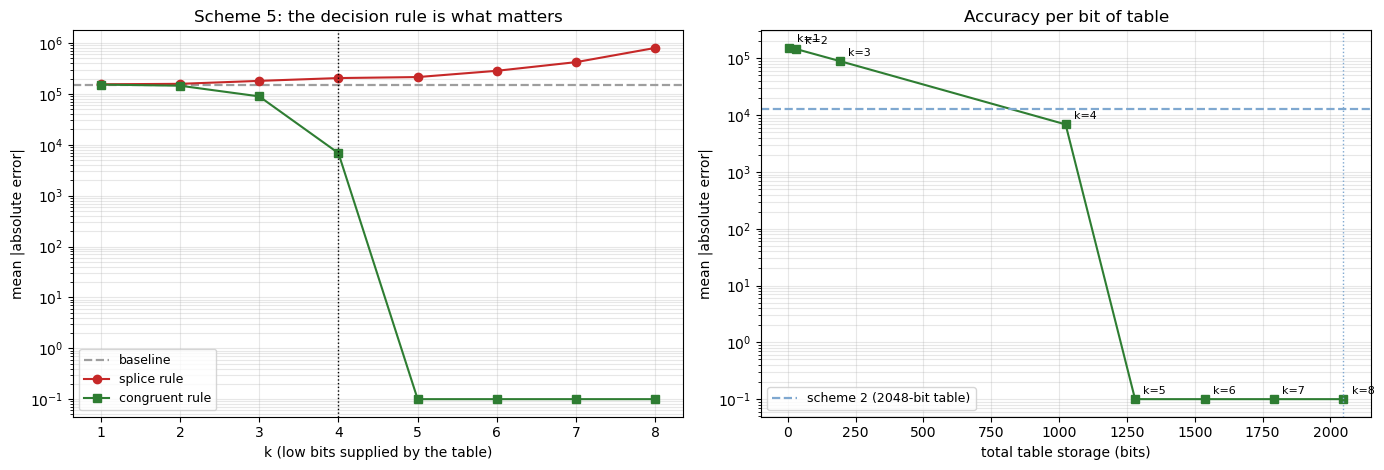

In [16]:
# -- Figure: k sweep ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

ax = axes[0]
ax.axhline(b_ma, color="#9e9e9e", ls="--", lw=1.6, label="baseline")
ax.plot(k_grid, sweep5["splice"], "o-", color="#c62828", ms=6, label="splice rule")
ax.plot(k_grid, [max(v, 1e-1) for v in sweep5["congruent"]], "s-", color="#2e7d32",
        ms=6, label="congruent rule")
ax.axvline(K_LOWBITS, color="black", ls=":", lw=1)
ax.set_yscale("log"); ax.set_xlabel("k (low bits supplied by the table)")
ax.set_ylabel("mean |absolute error|")
ax.set_title("Scheme 5: the decision rule is what matters")
ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=9)

ax = axes[1]
bits = [table_cost(k)[2] for k in k_grid]
ax.plot(bits, [max(v, 1e-1) for v in sweep5["congruent"]], "s-", color="#2e7d32", ms=6)
for k, x, y in zip(k_grid, bits, sweep5["congruent"]):
    ax.annotate(f"k={k}", (x, max(y, 1e-1)), textcoords="offset points",
                xytext=(6, 4), fontsize=8)
ax.axhline(results["lut4"]["mean_abs"], color="#7fa8d0", ls="--", lw=1.6,
           label=f"scheme 2 (2048-bit table)")
ax.axvline(2048, color="#7fa8d0", ls=":", lw=1)
ax.set_yscale("log"); ax.set_xlabel("total table storage (bits)")
ax.set_ylabel("mean |absolute error|")
ax.set_title("Accuracy per bit of table")
ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

## 8. Scheme 6: Low-Bit Decomposed Correction

### 8.1 Reducing the residue table

At \(k=4\), Scheme 5 directly indexes the full nibble pair and therefore uses a 256-entry
4-bit residue table. Scheme 6 computes the same residue from the 16-entry 2-bit product
table already used by Schemes 3 and 4.

Split each nibble as \(a=4a_{\mathrm{hi}}+a_{\mathrm{lo}}\) and
\(b=4b_{\mathrm{hi}}+b_{\mathrm{lo}}\). Then

\[
ab =
16a_{\mathrm{hi}}b_{\mathrm{hi}}
+4(a_{\mathrm{hi}}b_{\mathrm{lo}}+a_{\mathrm{lo}}b_{\mathrm{hi}})
+a_{\mathrm{lo}}b_{\mathrm{lo}}.
\]

Modulo 16, the first term vanishes, giving

\[
ab \bmod 16 =
\left[
4(a_{\mathrm{hi}}b_{\mathrm{lo}}+a_{\mathrm{lo}}b_{\mathrm{hi}})
+a_{\mathrm{lo}}b_{\mathrm{lo}}
\right] \bmod 16.
\]

The three remaining products are all 2-bit by 2-bit values and can be read from one
16-entry table.

### 8.2 Cost and equivalence

Scheme 6 uses three table reads per residue instead of one direct residue lookup. It also
requires two small additions, a fixed shift and truncation modulo 16. These operations are
reported separately from photonic sub-product count because no RTL synthesis was performed.

The photonic grid is unchanged from Scheme 5. Since both schemes supply the same exact
4-bit residue to the same congruent decoder, they are numerically identical under the
ideal-table model. The exhaustive check below verifies the residue identity over all 256
nibble pairs.


In [17]:
# -- The decomposition, verified exhaustively ---------------------------------
def residue_decomposed(a_nib, b_nib, lut2):
    """(a*b) mod 16 computed from three reads of a 16-entry 2-bit product table.
    The a_hi*b_hi partial product carries weight 16 and cannot affect the low 4 bits,
    so it is never computed."""
    a_hi, a_lo = a_nib >> 2, a_nib & 3
    b_hi, b_lo = b_nib >> 2, b_nib & 3
    return int((4 * (lut2[a_hi, b_lo] + lut2[a_lo, b_hi]) + lut2[a_lo, b_lo]) % 16)


_bad = [(a, b) for a in range(16) for b in range(16)
        if residue_decomposed(a, b, LUT_2bit) != (a * b) % 16]
print(f"Exhaustive verification over all 256 nibble pairs: {256-len(_bad)}/256 correct")
assert not _bad, f"decomposition failed on {_bad[:5]}"
print()
print("Worked example, the canonical MSB corner 13 x 10 = 130:")
_a, _b = 13, 10
_ah, _al, _bh, _bl = _a >> 2, _a & 3, _b >> 2, _b & 3
print(f"  13 = 4*{_ah} + {_al}      10 = 4*{_bh} + {_bl}")
print(f"  a_hi x b_lo : LUT_2bit[{_ah},{_bl}] = {LUT_2bit[_ah,_bl]}   weight 4")
print(f"  a_lo x b_hi : LUT_2bit[{_al},{_bh}] = {LUT_2bit[_al,_bh]}   weight 4")
print(f"  a_lo x b_lo : LUT_2bit[{_al},{_bl}] = {LUT_2bit[_al,_bl]}   weight 1")
print(f"  a_hi x b_hi : LUT_2bit[{_ah},{_bh}] = {LUT_2bit[_ah,_bh]}   weight 16  NEVER COMPUTED")
print(f"  (4*({LUT_2bit[_ah,_bl]} + {LUT_2bit[_al,_bh]}) + {LUT_2bit[_al,_bl]}) mod 16 = "
      f"{residue_decomposed(_a,_b,LUT_2bit)}")
print(f"  true: 130 mod 16 = {130 % 16}")
print()
print("The complete 16-entry table (this is LUT_2bit from Section 3):")
print("        " + "".join(f"{y:>4}" for y in range(4)))
for x in range(4):
    print(f"    {x}   " + "".join(f"{LUT_2bit[x,y]:>4}" for y in range(4)))
print(f"    16 entries, 4 bits each = {16*4} bits total")

Exhaustive verification over all 256 nibble pairs: 256/256 correct

Worked example, the canonical MSB corner 13 x 10 = 130:
  13 = 4*3 + 1      10 = 4*2 + 2
  a_hi x b_lo : LUT_2bit[3,2] = 6   weight 4
  a_lo x b_hi : LUT_2bit[1,2] = 2   weight 4
  a_lo x b_lo : LUT_2bit[1,2] = 2   weight 1
  a_hi x b_hi : LUT_2bit[3,2] = 6   weight 16  NEVER COMPUTED
  (4*(6 + 2) + 2) mod 16 = 2
  true: 130 mod 16 = 2

The complete 16-entry table (this is LUT_2bit from Section 3):
           0   1   2   3
    0      0   0   0   0
    1      0   1   2   3
    2      0   2   4   6
    3      0   3   6   9
    16 entries, 4 bits each = 64 bits total


In [18]:
# -- Scheme 6 multiply ---------------------------------------------------------
def bitlume_multiply_lowbit_decomposed(a, b, n_nibbles, mu, sigma,
                                       lut2=None, verbose=False) -> dict:
    """Scheme 5's congruent decoder, but the k=4 residue is computed from a
    16-entry 2-bit table instead of read from a 256-entry table. Photonic sub-product
    count is unchanged."""
    lut2 = LUT_2bit if lut2 is None else lut2
    ground_truth = int(a) * int(b)
    a_nibbles = decompose_into_nibbles(a, n_nibbles)
    b_nibbles = decompose_into_nibbles(b, n_nibbles)

    positions = [(i, j) for i in range(1, n_nibbles + 1) for j in range(1, n_nibbles + 1)]
    Z = grid_standard_normals(a, b, positions, FAM_NIBBLE)
    m4, s4 = noise_for(4, 4, mu, sigma)
    M = 16

    photonic_sum, n_reads = 0.0, 0
    for (i, j) in positions:
        av, bv = a_nibbles[i - 1], b_nibbles[j - 1]
        noisy = av * bv + m4 + s4 * Z[(i, j)]
        z = noisy - m4
        r = residue_decomposed(av, bv, lut2)          # 3 reads of the 16-entry table
        n_reads += 3
        blk = np.floor((z - r) / M)
        pp = float(min([(blk + o) * M + r for o in (-1, 0, 1)], key=lambda u: abs(u - z)))
        photonic_sum += pp * (2 ** (4 * (i + j - 2)))

    abs_error = photonic_sum - ground_truth
    rel_error = abs(abs_error) / ground_truth * 100 if ground_truth else 0.0
    return {"a": a, "b": b, "ground_truth": ground_truth, "photonic_result": photonic_sum,
            "absolute_error": abs_error, "relative_error_pct": rel_error,
            "n_subproducts": n_nibbles ** 2, "n_table_reads": n_reads}


# Equivalence check against scheme 5
_d = np.array([abs(bitlume_multiply_lowbit_decomposed(int(a), int(b), N_NIBBLES,
                                                      mu, sigma)["absolute_error"])
               for a, b in zip(allA, allB)])
_s5 = np.array([abs(bitlume_multiply_lowbit(int(a), int(b), N_NIBBLES,
                                            mu, sigma)["absolute_error"])
                for a, b in zip(allA, allB)])
print(f"Scheme 5 (256-entry table)  mean |abs err| : {_s5.mean():>12,.2f}")
print(f"Scheme 6 (16-entry, decomposed)            : {_d.mean():>12,.2f}")
print(f"Maximum per-pair difference                : {np.abs(_d - _s5).max():>12.2e}")
assert np.allclose(_d, _s5), "decomposed scheme diverged from scheme 5"
print()
print("IDENTICAL on every one of the 500 pairs, as it must be: the decomposition computes")
print("the same residue, so the decoder reaches the same decision every time. The 16x")
print("storage reduction is free in accuracy terms.")

Scheme 5 (256-entry table)  mean |abs err| :     6,857.22
Scheme 6 (16-entry, decomposed)            :     6,857.22
Maximum per-pair difference                :     0.00e+00

IDENTICAL on every one of the 500 pairs, as it must be: the decomposition computes
the same residue, so the decoder reaches the same decision every time. The 16x
storage reduction is free in accuracy terms.


## 9. Collated Results: All Six Schemes

In [19]:
# -- Add scheme 5 to the results dictionary -----------------------------------
_rs = [bitlume_multiply_lowbit(int(a), int(b), N_NIBBLES, mu, sigma)
       for a, b in zip(allA, allB)]
_ae = np.array([abs(r["absolute_error"]) for r in _rs])
_re = np.array([r["relative_error_pct"] for r in _rs])
results["lowbit"] = {"mean_abs": _ae.mean(), "median_abs": np.median(_ae),
                     "mean_rel": _re.mean(), "median_rel": np.median(_re),
                     "abs_errs": _ae, "nsub": N_NIBBLES ** 2,
                     "label": f"5. Low-bit congruent (k={K_LOWBITS})"}

_rd = [bitlume_multiply_lowbit_decomposed(int(a), int(b), N_NIBBLES, mu, sigma)
       for a, b in zip(allA, allB)]
_ad = np.array([abs(r["absolute_error"]) for r in _rd])
_rr = np.array([r["relative_error_pct"] for r in _rd])
results["decomp"] = {"mean_abs": _ad.mean(), "median_abs": np.median(_ad),
                     "mean_rel": _rr.mean(), "median_rel": np.median(_rr),
                     "abs_errs": _ad, "nsub": N_NIBBLES ** 2,
                     "label": "6. Low-bit decomposed"}

ORDER = ["base", "lut4", "nonuni", "parallel", "lowbit", "decomp"]
TABLE_BITS = {"base": 0, "lut4": 256 * 8, "nonuni": 16 * 4,
              "parallel": 16 * 4, "lowbit": table_cost(K_LOWBITS)[2], "decomp": 16 * 4}
TABLE_DESC = {"base": "none", "lut4": "256 x 8b", "nonuni": "16 x 4b",
              "parallel": "16 x 4b", "lowbit": f"{table_cost(K_LOWBITS)[0]} x {K_LOWBITS}b",
              "decomp": "16 x 4b"}

print(f"All Six Schemes | FP16 ({MANTISSA_BIT_WIDTH}-bit mantissa) | N = {N_ALL} | sigma = {sigma}")
print("=" * 140)
print(f"{'Scheme':<34}{'Sub-':>7}{'Over-':>8}{'Table':>10}{'Table':>8}"
      f"{'Mean |Abs Err|':>17}{'vs base':>10}{'Median |Abs|':>15}{'Mean Rel%':>11}{'Median Rel%':>12}")
print(f"{'':<34}{'prods':>7}{'head':>8}{'':>10}{'bits':>8}{'':>17}{'':>10}{'':>15}{'':>11}{'':>12}")
print("-" * 140)
for s in ORDER:
    d = results[s]
    oh = (d["nsub"] - N_NIBBLES ** 2) / N_NIBBLES ** 2 * 100
    print(f"{d['label']:<34}{d['nsub']:>7}{oh:>7.1f}%{TABLE_DESC[s]:>10}{TABLE_BITS[s]:>8}"
          f"{d['mean_abs']:>17,.2f}{(d['mean_abs']-b_ma)/b_ma*100:>9.1f}%"
          f"{d['median_abs']:>15,.2f}{d['mean_rel']:>10.4f}%{d['median_rel']:>11.4f}%")
print("=" * 140)

All Six Schemes | FP16 (12-bit mantissa) | N = 500 | sigma = 2.7588
Scheme                               Sub-   Over-     Table   Table   Mean |Abs Err|   vs base   Median |Abs|  Mean Rel% Median Rel%
                                    prods    head              bits                                                                 
--------------------------------------------------------------------------------------------------------------------------------------------
1. Baseline 4-bit                       9    0.0%      none       0       152,411.29      0.0%     124,129.64   61.6462%     4.1998%
2. 4-bit + LUT (MSB corner)             9    0.0%  256 x 8b    2048        12,627.04    -91.7%      10,627.22    4.6431%     0.2911%
3. Non-uniform slicing + LUT           16   77.8%   16 x 4b      64        53,263.36    -65.1%      43,325.76   35.6115%     1.3253%
4. Parallel non-uniform + LUT          12   33.3%   16 x 4b      64        12,627.04    -91.7%      10,627.22    4.6431%     0

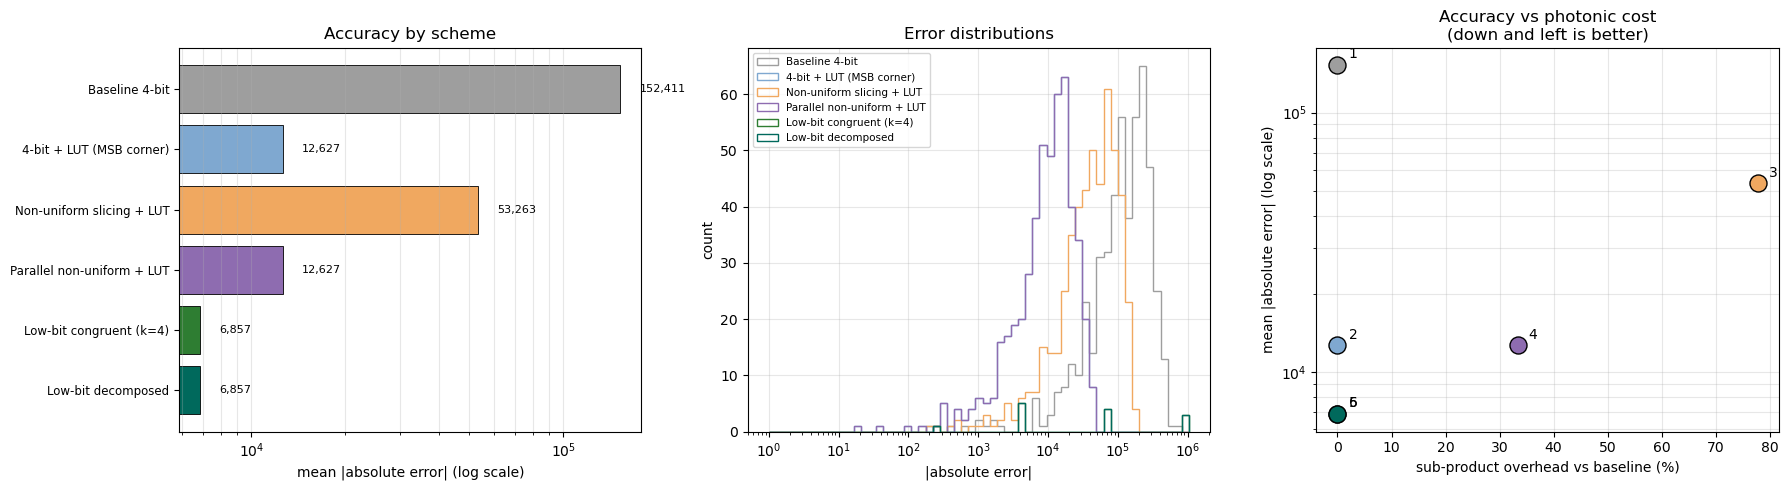

In [20]:
# -- Figures: six-scheme comparison -------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

labels = [results[s]["label"].split(". ", 1)[1] for s in ORDER]
vals = [results[s]["mean_abs"] for s in ORDER]
cols = ["#9e9e9e", "#7fa8d0", "#f0a860", "#8e6cb0", "#2e7d32", "#00695c"]

ax = axes[0]
ax.barh(range(len(ORDER)), [max(v, 1e-1) for v in vals], color=cols,
        edgecolor="black", lw=0.6)
ax.set_yticks(range(len(ORDER))); ax.set_yticklabels(labels, fontsize=8.5)
ax.invert_yaxis(); ax.set_xscale("log")
ax.set_xlabel("mean |absolute error| (log scale)")
ax.set_title("Accuracy by scheme")
ax.grid(axis="x", alpha=0.3, which="both")
for i, v in enumerate(vals):
    ax.text(max(v, 1e-1) * 1.15, i, f"{v:,.0f}", va="center", fontsize=8)

ax = axes[1]
_mx = max(results[s]["abs_errs"].max() for s in ORDER)
bins = np.logspace(0, np.log10(max(_mx, 10)), 60)
for s, c in zip(ORDER, cols):
    e = np.clip(results[s]["abs_errs"], 1e-9, None)
    ax.hist(e, bins=bins, histtype="step", lw=1.7, color=c,
            label=results[s]["label"].split(". ", 1)[1])
ax.set_xscale("log"); ax.set_xlabel("|absolute error|"); ax.set_ylabel("count")
ax.set_title("Error distributions"); ax.legend(fontsize=7.5); ax.grid(alpha=0.3)

ax = axes[2]
for s, c in zip(ORDER, cols):
    d = results[s]
    oh = (d["nsub"] - N_NIBBLES ** 2) / N_NIBBLES ** 2 * 100
    ax.scatter(oh, max(d["mean_abs"], 1e-1), s=150, color=c, edgecolor="black", zorder=3)
    ax.annotate(d["label"].split(".")[0], (oh, max(d["mean_abs"], 1e-1)),
                textcoords="offset points", xytext=(8, 5), fontsize=10)
ax.set_yscale("log"); ax.set_xlabel("sub-product overhead vs baseline (%)")
ax.set_ylabel("mean |absolute error| (log scale)")
ax.set_title("Accuracy vs photonic cost\n(down and left is better)")
ax.grid(alpha=0.3, which="both")

plt.tight_layout(); plt.show()

## 10. FP32

In [21]:
# -- FP32 configuration (leaves the FP16 globals untouched) -------------------
FP32_MANT_BITS = 24
FP32_NIBBLES   = FP32_MANT_BITS // 4       # 6
FP32_MAX       = 2 ** FP32_MANT_BITS - 1
FP32_N         = 200

fA = np.random.default_rng(SEED + 3200).integers(0, FP32_MAX + 1, size=FP32_N)
fB = np.random.default_rng(SEED + 3201).integers(0, FP32_MAX + 1, size=FP32_N)

FP32_NSUB = {"base": FP32_NIBBLES ** 2, "lut4": FP32_NIBBLES ** 2,
             "nonuni": (FP32_NIBBLES + 1) ** 2, "parallel": FP32_NIBBLES ** 2 + 3,
             "lowbit": FP32_NIBBLES ** 2, "decomp": FP32_NIBBLES ** 2}

def run_fp32(a, b, s):
    a, b = int(a), int(b)
    if s == "base":     return bitlume_multiply(a, b, FP32_NIBBLES, mu, sigma)
    if s == "lut4":     return bitlume_multiply_with_lut(a, b, FP32_NIBBLES, mu, sigma,
                                                         lut=LUT, lut_position="msb")
    if s == "nonuni":   return bitlume_multiply_nonuniform(a, b, FP32_NIBBLES, mu, sigma,
                                                           None, lut2=LUT_2bit, use_lut=True)
    if s == "parallel": return bitlume_multiply_parallel(a, b, FP32_NIBBLES, mu, sigma,
                                                         None, lut2=LUT_2bit, use_lut=True)
    if s == "lowbit":   return bitlume_multiply_lowbit(a, b, FP32_NIBBLES, mu, sigma)
    if s == "decomp":   return bitlume_multiply_lowbit_decomposed(a, b, FP32_NIBBLES,
                                                                  mu, sigma)
    raise ValueError(s)

fp32 = {}
for s in ORDER:
    rs = [run_fp32(a, b, s) for a, b in zip(fA, fB)]
    ae = np.array([abs(r["absolute_error"]) for r in rs])
    re = np.array([r["relative_error_pct"] for r in rs])
    fp32[s] = {"mean_abs": ae.mean(), "median_abs": np.median(ae),
               "mean_rel": re.mean(), "nsub": FP32_NSUB[s]}

fb = fp32["base"]["mean_abs"]
print(f"All Six Schemes | FP32 ({FP32_MANT_BITS}-bit mantissa) | N = {FP32_N} | sigma = {sigma}")
print("=" * 116)
print(f"{'Scheme':<34}{'Sub-prods':>11}{'Overhead':>10}{'Mean |Abs Err|':>20}"
      f"{'vs base':>10}{'Median |Abs|':>18}{'Mean Rel%':>12}")
print("-" * 116)
for s in ORDER:
    d = fp32[s]
    oh = (d["nsub"] - FP32_NIBBLES ** 2) / FP32_NIBBLES ** 2 * 100
    print(f"{results[s]['label']:<34}{d['nsub']:>11}{oh:>9.1f}%{d['mean_abs']:>20,.4g}"
          f"{(d['mean_abs']-fb)/fb*100:>9.1f}%{d['median_abs']:>18,.4g}{d['mean_rel']:>11.4f}%")
print("=" * 116)
print()
print("Scheme 4's overhead falls from +33.3% at FP16 to "
      f"{(FP32_NIBBLES**2+3-FP32_NIBBLES**2)/FP32_NIBBLES**2*100:.1f}% at FP32, and scheme 3's from")
print(f"+77.8% to {((FP32_NIBBLES+1)**2-FP32_NIBBLES**2)/FP32_NIBBLES**2*100:.1f}%. "
      "Schemes 5 and 6 stay at zero photonic overhead at every")
print("precision under the sub-product proxy. They are also")
print("identical to each other at FP32, confirming the decomposition holds independently")
print("of mantissa width.")

All Six Schemes | FP32 (24-bit mantissa) | N = 200 | sigma = 2.7588
Scheme                              Sub-prods  Overhead      Mean |Abs Err|   vs base      Median |Abs|   Mean Rel%
--------------------------------------------------------------------------------------------------------------------
1. Baseline 4-bit                          36      0.0%           2.642e+12      0.0%         2.394e+12    28.0713%
2. 4-bit + LUT (MSB corner)                36      0.0%           2.241e+11    -91.5%         1.928e+11     2.0156%
3. Non-uniform slicing + LUT               49     36.1%           8.545e+11    -67.7%         6.616e+11     5.7490%
4. Parallel non-uniform + LUT              39      8.3%           2.241e+11    -91.5%         1.928e+11     2.0156%
5. Low-bit congruent (k=4)                 36      0.0%           9.392e+10    -96.4%                 0     0.1175%
6. Low-bit decomposed                      36      0.0%           9.392e+10    -96.4%                 0     0.1175%

Sc

## 11. Analytical Cost Model

Photonic sub-product count is used as the primary photonic-path cost proxy. It is not a
literal count of DAC or ADC transactions because BITLUME reuses operands after conversion.

For the system-level projection, the sub-product ratio is applied to the fractions reported
by BITLUME. The photonic core accounts for about 41.5% of dot-product latency, while data
conversion accounts for 68.44% of power. The resulting latency and energy multipliers are
first-order analytical estimates rather than hardware measurements.

BITLUME reports baseline speedups against an A100 of 13.43x at FP16 and 10.78x at FP32.
Those values are scaled by the projected latency multiplier below. Added digital
post-processing is not included in the system-level projection and is reported separately.


In [22]:
# Photonic sub-product counts used by the analytical proxy.
BITLUME_BASE_SUBPRODUCTS = {"FP16": 9, "FP32": 36}
BITLUME_VS_A100 = {"FP16": {"speedup": 13.43},
                   "FP32": {"speedup": 10.78}}

PHOTONIC_LATENCY_FRACTION = 0.415
CONVERTER_POWER_FRACTION  = 0.6844

NIBBLES_BY_PRECISION = {"FP16": 3, "FP32": 6}

def scheme_subproducts(precision, scheme):
    n = NIBBLES_BY_PRECISION[precision]
    if scheme in ("base", "lut4", "lowbit", "decomp"):
        return n * n
    if scheme == "nonuni":
        return (n + 1) ** 2
    if scheme == "parallel":
        return n * n + 3
    raise ValueError(scheme)

print("Photonic sub-product count")
print("=" * 82)
print(f"{'Precision':>9}  {'Scheme':<34}{'Sub-products':>14}{'vs baseline':>14}")
print("-" * 82)
for prec in ["FP16", "FP32"]:
    base_sp = scheme_subproducts(prec, "base")
    for s in ORDER:
        sp = scheme_subproducts(prec, s)
        print(f"{prec:>9}  {results[s]['label']:<34}{sp:>14}{sp/base_sp:>13.2f}x")
    print("-" * 82)
print("Sub-product count is a photonic-path proxy, not a one-to-one converter-cycle count.")

Photonic sub-product count
Precision  Scheme                              Sub-products   vs baseline
----------------------------------------------------------------------------------
     FP16  1. Baseline 4-bit                              9         1.00x
     FP16  2. 4-bit + LUT (MSB corner)                    9         1.00x
     FP16  3. Non-uniform slicing + LUT                  16         1.78x
     FP16  4. Parallel non-uniform + LUT                 12         1.33x
     FP16  5. Low-bit congruent (k=4)                     9         1.00x
     FP16  6. Low-bit decomposed                          9         1.00x
----------------------------------------------------------------------------------
     FP32  1. Baseline 4-bit                             36         1.00x
     FP32  2. 4-bit + LUT (MSB corner)                   36         1.00x
     FP32  3. Non-uniform slicing + LUT                  49         1.36x
     FP32  4. Parallel non-uniform + LUT                 39        

In [23]:
# Projected system impact under the sub-product scaling model.
print("Projected System Impact")
print("=" * 108)
print(f"{'Precision':>9}  {'Scheme':<34}{'SP ratio':>10}{'Latency':>10}{'Energy':>10}"
      f"{'Speedup vs A100':>18}")
print("-" * 108)

cost_rows = []
for prec in ["FP16", "FP32"]:
    base_sp = scheme_subproducts(prec, "base")
    for s in ORDER:
        sp = scheme_subproducts(prec, s)
        ratio = sp / base_sp
        lat_impact = 1 + PHOTONIC_LATENCY_FRACTION * (ratio - 1)
        eng_impact = 1 + CONVERTER_POWER_FRACTION * (ratio - 1)
        speedup = BITLUME_VS_A100[prec]["speedup"] / lat_impact
        cost_rows.append({"prec": prec, "scheme": s, "sp": sp, "ratio": ratio,
                          "lat": lat_impact, "eng": eng_impact, "speedup": speedup})
        print(f"{prec:>9}  {results[s]['label']:<34}{ratio:>9.2f}x{lat_impact:>9.2f}x"
              f"{eng_impact:>9.2f}x{speedup:>15.2f}x")
    print("-" * 108)
print("=" * 108)
print()
print("Latency and energy are normalised multipliers relative to baseline BITLUME under the")
print("analytical scaling model. The A100 column is a projected speedup obtained by applying")
print("the latency multiplier to BITLUME's reported baseline speedup.")
print("Digital lookup and decode costs are not included in these projections.")

Projected System Impact
Precision  Scheme                              SP ratio   Latency    Energy   Speedup vs A100
------------------------------------------------------------------------------------------------------------
     FP16  1. Baseline 4-bit                      1.00x     1.00x     1.00x          13.43x
     FP16  2. 4-bit + LUT (MSB corner)            1.00x     1.00x     1.00x          13.43x
     FP16  3. Non-uniform slicing + LUT           1.78x     1.32x     1.53x          10.15x
     FP16  4. Parallel non-uniform + LUT          1.33x     1.14x     1.23x          11.80x
     FP16  5. Low-bit congruent (k=4)             1.00x     1.00x     1.00x          13.43x
     FP16  6. Low-bit decomposed                  1.00x     1.00x     1.00x          13.43x
------------------------------------------------------------------------------------------------------------
     FP32  1. Baseline 4-bit                      1.00x     1.00x     1.00x          10.78x
     FP32  2. 4-bit 

### 11.1 Digital Post-Processing Requirements

Sub-product count does not capture the additional digital work introduced by the low-bit
schemes. The table below therefore reports algorithmic requirements directly. Heterogeneous
operations are not combined into a synthetic total because a table read, addition,
comparison and fixed shift do not have a common hardware cost. No cycle, area or energy
values are inferred without RTL synthesis.


In [24]:
def digital_profile(precision, scheme):
    n = NIBBLES_BY_PRECISION[precision]
    sp = n * n
    if scheme == "base":
        return {"reads": 0, "decodes": 0, "residue": "none"}
    if scheme == "lut4":
        return {"reads": 1, "decodes": 0, "residue": "none"}
    if scheme in ("nonuni", "parallel"):
        return {"reads": 4, "decodes": 0, "residue": "none"}
    if scheme == "lowbit":
        return {"reads": sp, "decodes": sp, "residue": "direct lookup"}
    if scheme == "decomp":
        return {"reads": 3 * sp, "decodes": sp,
                "residue": "3 LUT reads + small integer arithmetic"}
    raise ValueError(scheme)

print("Digital post-processing requirements")
print("=" * 112)
print(f"{'Precision':>9}  {'Scheme':<34}{'Sub-products':>14}{'Table reads':>13}"
      f"{'Decodes':>10}  {'Residue computation'}")
print("-" * 112)
for prec in ["FP16", "FP32"]:
    for s in ORDER:
        d = digital_profile(prec, s)
        print(f"{prec:>9}  {results[s]['label']:<34}{scheme_subproducts(prec,s):>14}"
              f"{d['reads']:>13}{d['decodes']:>10}  {d['residue']}")
    print("-" * 112)
print("No total operation count is reported because these primitives were not synthesised.")

Digital post-processing requirements
Precision  Scheme                              Sub-products  Table reads   Decodes  Residue computation
----------------------------------------------------------------------------------------------------------------
     FP16  1. Baseline 4-bit                              9            0         0  none
     FP16  2. 4-bit + LUT (MSB corner)                    9            1         0  none
     FP16  3. Non-uniform slicing + LUT                  16            4         0  none
     FP16  4. Parallel non-uniform + LUT                 12            4         0  none
     FP16  5. Low-bit congruent (k=4)                     9            9         9  direct lookup
     FP16  6. Low-bit decomposed                          9           27         9  3 LUT reads + small integer arithmetic
----------------------------------------------------------------------------------------------------------------
     FP32  1. Baseline 4-bit                            

In [25]:
print("Scheme 5 vs Scheme 6")
print("=" * 92)
print(f"{'Metric':<40}{'Scheme 5':>18}{'Scheme 6':>18}{'Change':>16}")
print("-" * 92)

d5 = digital_profile("FP16", "lowbit")
d6 = digital_profile("FP16", "decomp")
rows = [
    ("Mean |abs error| (FP16)", f"{results['lowbit']['mean_abs']:,.2f}",
     f"{results['decomp']['mean_abs']:,.2f}", "identical"),
    ("Photonic sub-products", "9", "9", "unchanged"),
    ("Table entries", "256", "16", "16x smaller"),
    ("Table storage (bits)", "1024", "64", "16x smaller"),
    ("Calibration combinations", "256", "16", "16x fewer"),
    ("Table reads per multiply", str(d5["reads"]), str(d6["reads"]), "3x more"),
    ("Congruent decodes", str(d5["decodes"]), str(d6["decodes"]), "same"),
    ("Residue method", "direct lookup", "decomposed", "more logic"),
]
for a, b, c, e in rows:
    print(f"{a:<40}{b:>18}{c:>18}{e:>16}")
print("=" * 92)
print()
print("Scheme 6 preserves Scheme 5's numerical behaviour while replacing the 256-entry")
print("residue table with the shared 16-entry 2-bit table. Its additional digital arithmetic")
print("is not assigned a latency or energy cost in this notebook.")

Scheme 5 vs Scheme 6
Metric                                            Scheme 5          Scheme 6          Change
--------------------------------------------------------------------------------------------
Mean |abs error| (FP16)                           6,857.22          6,857.22       identical
Photonic sub-products                                    9                 9       unchanged
Table entries                                          256                16     16x smaller
Table storage (bits)                                  1024                64     16x smaller
Calibration combinations                               256                16       16x fewer
Table reads per multiply                                 9                27         3x more
Congruent decodes                                        9                 9            same
Residue method                               direct lookup        decomposed      more logic

Scheme 6 preserves Scheme 5's numerical behaviou

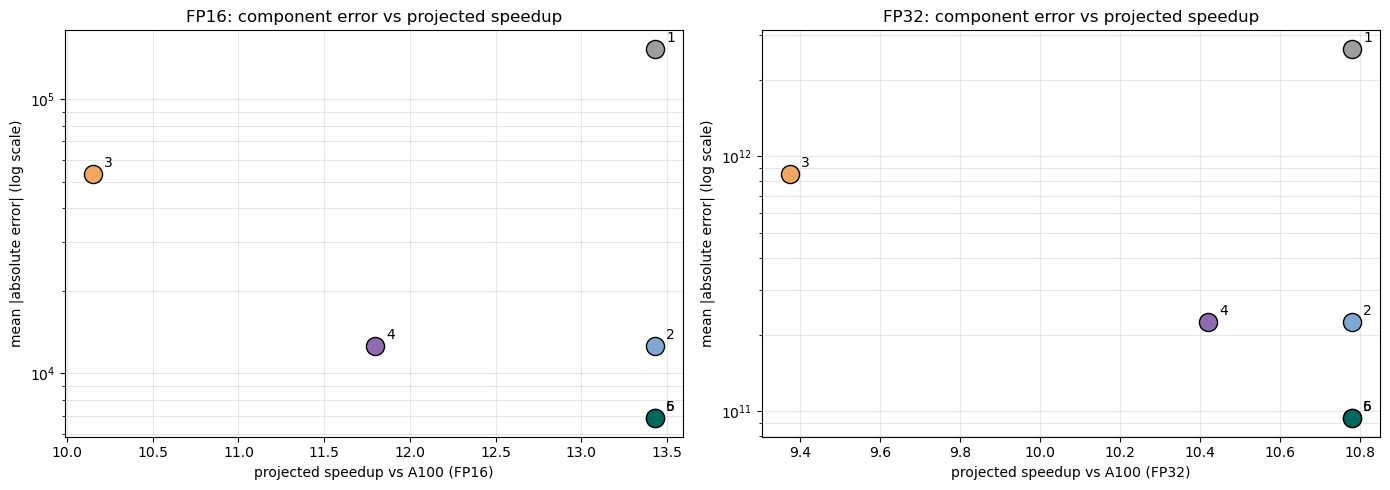

The speedup axis uses the analytical sub-product scaling model and does not include
additional digital post-processing for the corrected schemes.


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, prec, acc in [(axes[0], "FP16", results), (axes[1], "FP32", fp32)]:
    for s, c in zip(ORDER, cols):
        row = [r for r in cost_rows if r["prec"] == prec and r["scheme"] == s][0]
        y = max(acc[s]["mean_abs"], 1e-1)
        ax.scatter(row["speedup"], y, s=170, color=c, edgecolor="black", zorder=3)
        ax.annotate(results[s]["label"].split(".")[0], (row["speedup"], y),
                    textcoords="offset points", xytext=(8, 5), fontsize=10)
    ax.set_yscale("log")
    ax.set_xlabel(f"projected speedup vs A100 ({prec})")
    ax.set_ylabel("mean |absolute error| (log scale)")
    ax.set_title(f"{prec}: component error vs projected speedup")
    ax.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()
print("The speedup axis uses the analytical sub-product scaling model and does not include")
print("additional digital post-processing for the corrected schemes.")

## 12. Summary and Limitations

In [27]:
def _cost(prec, s, field):
    return [r for r in cost_rows if r["prec"] == prec and r["scheme"] == s][0][field]

print("=" * 142)
print(f"{'COMPONENT-LEVEL SUMMARY':^142}")
print(f"{'FP16 N = ' + str(N_ALL) + ', FP32 N = ' + str(FP32_N) + ', sigma = ' + str(sigma):^142}")
print("=" * 142)
hdr = (f"{'Scheme':<34}{'Table':>11}{'bits':>7}"
       f"{'|':>2}{'FP16 SP':>9}{'FP16 Mean|AE|':>16}{'reduction':>11}{'lat x':>8}{'A100 x':>9}"
       f"{'|':>2}{'FP32 SP':>9}{'FP32 Mean|AE|':>16}{'reduction':>11}")
print(hdr)
print("-" * 142)

for s in ORDER:
    d16, d32 = results[s], fp32[s]
    red16 = (b_ma - d16["mean_abs"]) / b_ma * 100
    red32 = (fb - d32["mean_abs"]) / fb * 100
    print(f"{d16['label']:<34}{TABLE_DESC[s]:>11}{TABLE_BITS[s]:>7}"
          f"{'|':>2}{_cost('FP16',s,'sp'):>9}{d16['mean_abs']:>16,.0f}{red16:>10.1f}%"
          f"{_cost('FP16',s,'lat'):>7.2f}x{_cost('FP16',s,'speedup'):>8.2f}x"
          f"{'|':>2}{_cost('FP32',s,'sp'):>9}{d32['mean_abs']:>16,.4g}{red32:>10.1f}%")
print("=" * 142)
print("SP is photonic sub-product count. lat x is the projected latency multiplier relative")
print("to baseline BITLUME. A100 x is projected speedup under the same analytical model.")

                                                           COMPONENT-LEVEL SUMMARY                                                            
                                                  FP16 N = 500, FP32 N = 200, sigma = 2.7588                                                  
Scheme                                  Table   bits |  FP16 SP   FP16 Mean|AE|  reduction   lat x   A100 x |  FP32 SP   FP32 Mean|AE|  reduction
----------------------------------------------------------------------------------------------------------------------------------------------
1. Baseline 4-bit                        none      0 |        9         152,411       0.0%   1.00x   13.43x |       36       2.642e+12       0.0%
2. 4-bit + LUT (MSB corner)          256 x 8b   2048 |        9          12,627      91.7%   1.00x   13.43x |       36       2.241e+11      91.5%
3. Non-uniform slicing + LUT          16 x 4b     64 |       16          53,263      65.1%   1.32x   10.15x |       49       8.545e+1

In [28]:
print("Summary")
print("=" * 86)
print(f"1. Low-bit congruent and low-bit decomposed correction have the lowest canonical")
print(f"   FP16 mean absolute error at sigma={sigma}: {results['lowbit']['mean_abs']:,.2f}.")
print("2. Schemes 2 and 4 implement the same exact MSB-corner correction under the")
print("   ideal-table model. Their remaining grid positions and keyed noise draws match.")
print("3. Scheme 4 reduces the corner table from 256 entries to 16 at the cost of three")
print("   additional FP16 photonic sub-products.")
print("4. Scheme 6 is numerically identical to Scheme 5 but obtains the residue from the")
print("   shared 16-entry table using three reads and small integer arithmetic per position.")
print()
print("Limitations")
print("=" * 86)
print("1. The 2-bit noise model is extrapolated and is used only for calibration realism")
print("   and uncorrected 2-bit controls. Runtime corrected 2-bit terms use exact table values.")
print("2. Final correction accuracy assumes ideal exact LUT contents after calibration.")
print("3. Latency and energy are analytical projections based on photonic sub-product count")
print("   and BITLUME's reported system fractions, not measurements of the proposed schemes.")
print("4. Added digital lookup and decode logic was not synthesised, so no cycle, area or")
print("   energy cost is assigned to it.")
print("5. These are component-level reconstruction results. Network-level accuracy is")
print("   evaluated separately in the DNN inference and noise-aware training notebooks.")

Summary
1. Low-bit congruent and low-bit decomposed correction have the lowest canonical
   FP16 mean absolute error at sigma=2.7588: 6,857.22.
2. Schemes 2 and 4 implement the same exact MSB-corner correction under the
   ideal-table model. Their remaining grid positions and keyed noise draws match.
3. Scheme 4 reduces the corner table from 256 entries to 16 at the cost of three
   additional FP16 photonic sub-products.
4. Scheme 6 is numerically identical to Scheme 5 but obtains the residue from the
   shared 16-entry table using three reads and small integer arithmetic per position.

Limitations
1. The 2-bit noise model is extrapolated and is used only for calibration realism
   and uncorrected 2-bit controls. Runtime corrected 2-bit terms use exact table values.
2. Final correction accuracy assumes ideal exact LUT contents after calibration.
3. Latency and energy are analytical projections based on photonic sub-product count
   and BITLUME's reported system fractions, not measureme